<a href="https://colab.research.google.com/github/zmgriffin/Data201-labs/blob/main/Lab01_week1_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Introduction to Python**:
Run the following cells

In [ ]:
print("Hello, DATA 201!")

Hello, DATA 201!


In [ ]:
x = 10
y = 5
x + y


15

**Loading Libraries in Python**

In Python, libraries are usually imported into their own namespace rather than being attached globally the way packages often are in R. For example, `import pandas as pd` imports the pandas library and gives it the short alias `pd`, so we can write `pd.DataFrame()` instead of `pandas.DataFrame()`. Similarly, `import matplotlib.pyplot as plt` imports the `pyplot` module from matplotlib and gives it the alias `plt`, allowing us to write commands such as `plt.plot()` and `plt.show()`. Python also allows us to import only a specific function or class, such as `from sklearn.datasets import load_iris`, which lets us call `load_iris()` directly. These conventions keep code organized, make it clear which library a function comes from, and reduce the amount of typing.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

penguins = pd.read_csv(url)


In [ ]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
penguins.keys()

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

Which penguin species has the greatest average body mass?

In [ ]:
penguins.groupby("species")["body_mass_g"].mean()

,body_mass_g
species,
Adelie,3700.662252
Chinstrap,3733.088235
Gentoo,5076.016260


**Visualization Task:** Bill Length vs. Flipper Length

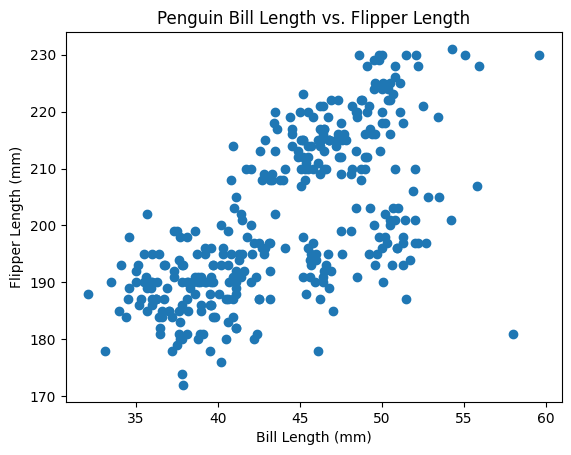

In [ ]:
plt.scatter(
    penguins["bill_length_mm"],
    penguins["flipper_length_mm"]
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Penguin Bill Length vs. Flipper Length")

plt.show()

## **A First Machine Learning Application:**
Classifying Iris Species (Adapted from IMLP-Chapter 1)

Suppose we have measurements of iris flowers whose species have already been identified by an expert.

For each flower, we know:

- Sepal length
- Sepal width
- Petal length
- Petal width

**Our goal is to use these measurements to predict the species of a new iris.**

The three possible species are:

- Setosa
- Versicolor
- Virginica

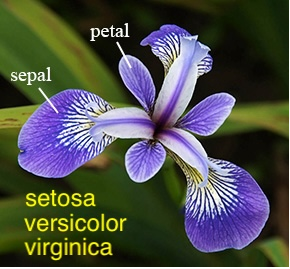


**Import Libraries:**
- NumPy → numerical arrays
- pandas → tables
- matplotlib → graphs
- scikit-learn → machine learning tools

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

**Load the Iris Dataset**

iris_dataset is not a Pandas DataFrame. In scikit-learn, load_iris() returns a special object called a Bunch, which behaves a lot like a Python dictionary

In [ ]:
# Load the built-in dataset
iris_dataset = load_iris()

iris_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
iris_dataset["data"]

#iris_dataset["feature_names"]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
#try the other keys

#iris_dataset["feature_names"]
iris_dataset["target"]
#iris_dataset["DESCR"]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### Question

What is:

- one sample? One flower
- the target? Species!
- the four features? petal and sepal length and width

In [ ]:
#What does the data look like
print(type(iris_dataset["data"])) # same as asking for class in R
print(iris_dataset["data"].shape)

<class 'numpy.ndarray'>
(150, 4)


In [ ]:
#Look up the first 4 flowers
iris_dataset["data"][:4]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2]])

In [ ]:
iris_dataset["feature_names"][:4]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
print(iris_dataset["target"].shape)
print(iris_dataset["target"])
print(iris_dataset["target_names"])

(150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [ ]:
# Convert it to a Pandas DataFrame for easy analysis
iris_df = pd.DataFrame(
    iris_dataset.data,     # add rows (observations)
    columns=iris_dataset.feature_names  #add columns(features)
)

# Add the target variable (species) as a new column
# 0 = setosa, 1 = versicolor, 2 = virginica
iris_df["species"] = iris_dataset.target

#print it
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## What kind of machine learning problem is this?

We know the correct species for the flowers in our dataset. Therefore: **Known target → Supervised Learning**

We also know that the target is a category: **Setosa, Versicolor, or Virginica** Therefore:**Categorical target → Classification**

## Training and Test Data
we cannot use the data we used to build the model to evaluate it. This
is because our model can always simply remember the whole training set, and will therefore always predict the correct label for any point in the training set.

This “remembering” does not indicate to us whether our model will generalize well (in other words, whether it will also perform well on new data).

To assess the model’s performance, we show it new data (data that it hasn’t seen before) for which we have labels. This is usually done by splitting the labeled data we have collected (here, our 150 flower measurements) into two parts.

- **Training set**: used to build the model
- **Test set**: used to evaluate the model on unseen data

**scikit-learn** contains a function that shuffles the dataset and splits it for you: the *train_test_split* function. This function extracts 75% of the rows in the data as the training set, together with the corresponding labels for this data. The remaining 25%
of the data, together with the remaining labels, is declared as the test set.

Deciding how much data you want to put into the training and the test set respectively is some‐
what arbitrary, but using a test set containing 25% of the data is a good rule of thumb.



Before making the split, the train_test_split function shuffles the dataset using a pseudorandom number generator, **"randome_state"**.

If we just took the last 25% of the data as a test set, all the data points would have the label 2, as the data points are sorted by the label (see the output for iris['target'] shown earlier).

**What would happen if we don not shuffle the data?**

To make sure that we will get the same output if we run the same function several times, we provide the pseudorandom number generator with a fixed seed using the random_state parameter. This will make the outcome deterministic, so this line will always have the same outcome.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset["data"],
    iris_dataset["target"],
    random_state=0
)

In [ ]:
#Check the size of the training and test sets

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(112, 4)
(112,)
(38, 4)
(38,)


Before we continue, we need to look at our Data. Before building a model, we need to inspect the data for patterns, abnormalities, or problems.

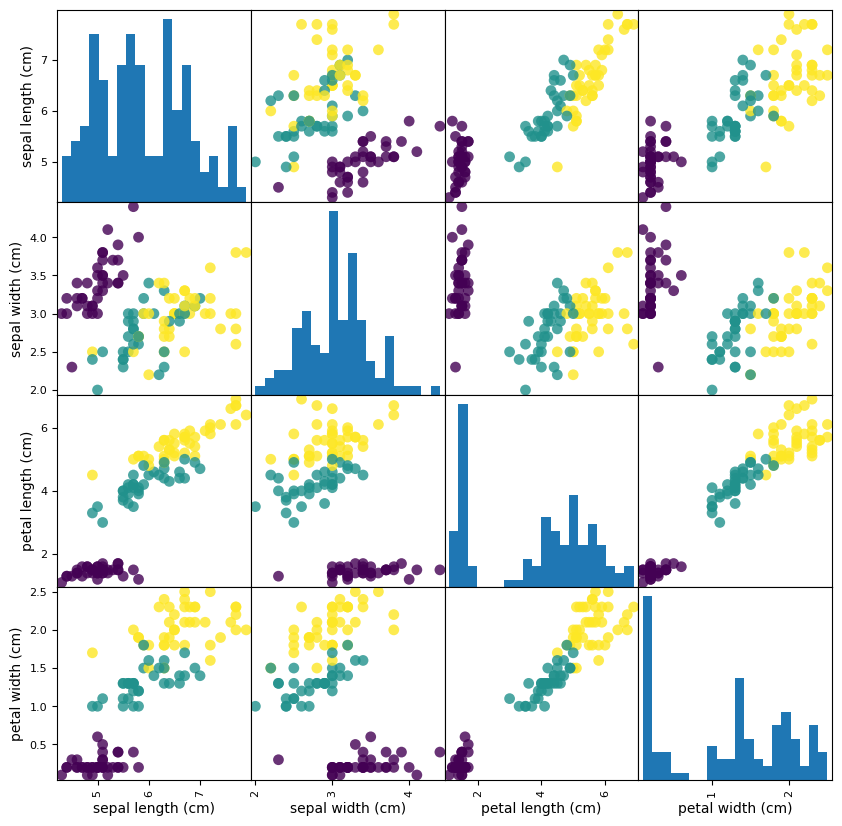

In [ ]:
iris_dataframe = pd.DataFrame(
    X_train,
    columns=iris_dataset.feature_names
)

pd.plotting.scatter_matrix(
    iris_dataframe,
    c=y_train,
    figsize=(10, 10),
    marker="o",
    hist_kwds={"bins": 20},
    s=60,
    alpha=0.8
)

plt.show()

From the plots, we can see that the three classes seem to be relatively well separated using the sepal and petal measurements. This means that a machine learning model will likely be able to learn to separate them.

## K-Nearest Neighbors

Now we can start building the actual machine learning model. There are many classification algorithms in scikit-learn that we could use. Here

- we will use a k-nearest neighbors classifier. Building this model only consists of storing the training set. To make a prediction for a new data point, the algorithm finds the point in the training set that is closest to the new point. Then it assigns the label of this training point to the new data point.

- The k in k-nearest neighbors signifies that instead of using only the closest neighbor to the new data point, we can consider any fixed number k of neighbors in the training (for example, the closest three or five neighbors).

- We will go into more detail about this in the future; for now, we will use only a single neighbor. **k = 1**.
So the model will use the single closest training observation.

You can read more about it: https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
#train the model
knn.fit(X_train, y_train)

#The model learn from the training data by passing X_train and y_train to fit()

KNeighborsClassifier(n_neighbors=1)

Now imagine we found an iris in the wild with a sepal length of
5 cm, a sepal width of 2.9 cm, a petal length of 1 cm, and a petal width of 0.2 cm.

What species of iris would this be?

In [ ]:
#Predict a New Iris
X_new = np.array([[5, 2.9, 1, 0.2]])

prediction = knn.predict(X_new)

print(iris_dataset["target_names"][prediction])


['setosa']


# Can we trust the prediction?

The model predicted **Setosa**.

But how do we know whether the model is generally good at predicting
iris species?

We use the test data-the observations that were not used to train the model.

In [ ]:
#Make prediction on test data
#y_pred contains the model's predicted species for all 38 flowers in the test set.
y_pred = knn.predict(X_test)

print(y_pred)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [ ]:
#Evaluate accuracy
print("Test set accuracy:")
print(knn.score(X_test, y_test))

Test set accuracy:
0.9736842105263158


For this model, the test set accuracy is about 0.97, which means we made the right prediction for 97% of the irises in the test set. We can expect our model to be correct 97% of the time for new
irises.

In the futute, we will discuss how we can improve performance, and what caveats there are in tuning a model.

## The Most Important Three Commands

- knn.fit(X_train, y_train)

- prediction = knn.predict(X_new)

- knn.score(X_test, y_test)


## A Basic scikit-learn Workflow

**fit():** Learn from the training data.

**predict()**: Use the model to predict an outcome.

**score()**: Evaluate how well the model performs.